In [49]:
import pyscf
import numpy as np
import qrunch as qc
from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import (
    ReducedDensityMatrixCalculator,
)
from pyscf import gto, scf, fci, mp, mcscf
import matplotlib.pyplot as plt

from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform
    )

from dmdm.interface import DMDM

qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT overwrite. If you want to change the license, please run with overwrite=True. Thus e.g. qrunch.license add /path/to/license/kvantify_license.txt --overwrite


# Simple VQE comparison with Hatree-Fock baseline

The ground state is estiamted

In [39]:
# Define the molecule
molecule_name = "H2O"
active_space = "minimal"
molecule = MoleculeData.molecules[molecule_name]["coords"]

# Define the basis
basis = "sto-3g"

# Define the active space
num_active_orbs = MoleculeData.molecules[molecule_name][active_space]["num_active_orbs"]
num_active_alpha_electrons = MoleculeData.molecules[molecule_name][active_space]["num_active_alpha_electrons"]

## Classical FCI

In [33]:
# Get the HF ground state energy --> ground truth
# fci_gse, fci_vec = get_hf_gse_from_mol(molecule, basis)
mol = gto.M(
atom=molecule,
basis=basis,
unit='Angstrom',
)


hf_energy = mol.RHF().run()
moller_plesset = mp.MP2(hf_energy).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(moller_plesset)
cisolver = fci.FCI(mol, natorbs)
fci_gse, fci_vec = cisolver.kernel()
print(f"E(FCI) = {fci_gse}")

converged SCF energy = -74.9623593200333
E(RMP2) = -74.9988968573629  E_corr = -0.0365375373296451
E(SCS-RMP2) = -75.0044496453003  E_corr = -0.0420903252670397
E(FCI) = -75.01375703590894


In [29]:
fci_vec.shape

(15, 15)

In [41]:
# get rdms from FCI
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.make_dm1234('FCI4pdm_kern_sf', fci_vec, fci_vec, num_active_orbs, num_active_alpha_electrons*2)
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.reorder_dm1234(fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4) # comes in a different orientation.
h_mo = one_electron_integral_transform(natorbs, mol.intor("int1e_kin") + mol.intor("int1e_nuc"))
g_mo = two_electron_integral_transform(natorbs, mol.intor("int2e"))#

dmdm = DMDM(
        h_mo,
        g_mo,
        0,
        num_active_orbs,
        0,
        num_active_alpha_electrons,
        fci_rdm1,
        rdm2=fci_rdm2,
        rdm3=fci_rdm3,
        rdm4=fci_rdm4,
        # print_level=3,
    )


AssertionError: 

In [ ]:
x, y, z = mol.intor('int1e_r', comp=3)
MO_DM = [one_electron_integral_transform(natorbs, x), one_electron_integral_transform(natorbs, y), one_electron_integral_transform(natorbs, z)]

exc_energies = dmdm.get_excitation_energies()
osc_strengths = dmdm.get_oscillator_strength(MO_DM)

print("Excitation energies (a.u.): ", exc_energies)
print("Oscillator strengths: ", osc_strengths)

idx, max(abs(grad active)): 13 0.01851667975614938
Smallest Hessian eigenvalue: (-0.001460721081486911+0j)
Smallest diagonal element in the metric: 0.0032944860445118457
Excitation energies (a.u.):  [2.06330492 2.13013599 2.13013599 2.49353772 2.98709685 5.31006415
 5.37728933 5.37728933 5.42279942 5.42279942 5.47390923 5.71234399
 5.77133315 5.77133315 6.19496061 6.36142828 6.36142828 6.53512241
 8.38525406 9.89078842]
Oscillator strengths:  [5.76427245e-02 1.03546580e-01 1.03546580e-01 4.78449935e-02
 2.80711992e-03 1.27586107e-05 9.42111417e-05 9.42111417e-05
 4.05675104e-32 1.26519704e-30 1.18219763e-05 1.16540478e-05
 6.40389656e-05 6.40389656e-05 6.64939905e-08 5.43805712e-04
 5.43805712e-04 1.41365092e-04 1.51038124e-02 0.00000000e+00]


In [42]:
import numpy as np
from pyscf import gto, scf, mp, mcscf, fci, ao2mo

# ==========================================
# 1. Define Molecule
# ==========================================
# Water geometry: O at origin, H atoms at ~0.96 Angstrom, angle 104.5 deg
# Using standard bond length and angle
mol = gto.M(
    atom='''
    O  0.000000  0.000000  0.000000
    H  0.000000  0.756950  0.586100
    H  0.000000 -0.756950  0.586100
    ''',
    basis='cc-pvdz',  # Double-zeta basis set
    unit='Angstrom',
    symmetry=False,   # Disable symmetry for easier debugging (optional)
    verbose=4         # Print detailed output
)

print(f"Molecule: {mol.natm} atoms, {mol.nelectron} electrons, {mol.nao} basis functions")

# ==========================================
# 2. Hartree-Fock Reference
# ==========================================
mf = scf.RHF(mol).run()
print(f"\n--- RHF Energy: {mf.e_tot:.8f} Ha ---")

# ==========================================
# 3. MP2 for Natural Orbitals
# ==========================================
# MP2 provides better correlation info for generating Natural Orbitals
mp2 = mp.MP2(mf).run()
print(f"MP2 Correlation Energy: {mp2.e_corr:.8f} Ha")

# Generate Natural Orbitals (NOs)
# noons: Natural Orbital Occupation Numbers
# natorbs: Coefficients of Natural Orbitals
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

# Sort NOs by occupation number (descending) just to be safe
idx = np.argsort(noons)[::-1]
noons = noons[idx]
natorbs = natorbs[:, idx]

print(f"\n--- Natural Orbital Occupations (Top 10) ---")
for i, occ in enumerate(noons[:10]):
    print(f"Orbital {i}: {occ:.4f}")

System: uname_result(system='Linux', node='cachyos', release='6.19.6-2-cachyos', version='#1 SMP PREEMPT_DYNAMIC Fri, 06 Mar 2026 11:29:20 +0000', machine='x86_64')  Threads 6
Python 3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:48:32) [GCC 14.3.0]
numpy 2.4.3  scipy 1.15.3  h5py 3.15.1
Date: Mon Mar 30 19:21:24 2026
PySCF version 2.12.1
PySCF path  /home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 3
[INPUT] num. electrons = 10
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 O      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0
[INPUT]  2 H      0.000000000000   0.756950000000   0.586100000000 AA 

In [57]:
n_core = 1  # Freeze O 1s (2 electrons)
n_active = 4 # 4 active orbitals
n_active_elec = 4 # 6 active electrons (Total 8 valence - 2 frozen = 6? Or just 6 in the active space)
# Let's assume we want to correlate 6 electrons in 4 orbitals.
# Total electrons = 10. 
# If we freeze 1s (2e), we have 8 valence. 
# If we pick 4 orbitals, we can put 6 or 8 electrons. 
# Let's do CAS(6,4) which is a common test case.

# Select indices for active orbitals
# Skip the first 'n_core' (which are the 1s core)
# Then take the next 'n_active'
start_idx = n_core
end_idx = n_core + n_active
active_indices = list(range(start_idx, end_idx))

print(f"\n--- Active Space Selection ---")
print(f"Core orbitals frozen: {n_core}")
print(f"Active orbitals selected: {active_indices}")
print(f"Active electrons: {n_active_elec}")

# Slice the NO coefficients
natorbs_active = natorbs[:, active_indices]
print(f"Active NO shape: {natorbs_active.shape}")


--- Active Space Selection ---
Core orbitals frozen: 1
Active orbitals selected: [1, 2, 3, 4]
Active electrons: 4
Active NO shape: (24, 4)


In [58]:
# ==========================================
# 5. Transform Integrals to Active Space
# ==========================================
# Get 1-electron integrals (Kinetic + Nuclear)
h1 = mol.intor('int1e_kin') + mol.intor('int1e_nuc')
# Transform to active MO basis
h_mo = one_electron_integral_transform(natorbs_active, h1) # Shape: (n_active, n_active)

# Get 2-electron integrals
# Note: mol.intor('int2e') returns the full AO 4-index tensor
# We transform only the active subset
g_mo = two_electron_integral_transform(natorbs_active, mol.intor("int2e")) # Shape: (n_active, n_active, n_active, n_active)

print(f"\n--- Transformed Integrals ---")
print(f"h_mo shape: {h_mo.shape}")
print(f"g_mo shape: {g_mo.shape}")


--- Transformed Integrals ---
h_mo shape: (4, 4)
g_mo shape: (4, 4, 4, 4)


In [66]:
dm1, dm2, dm3, dm4 = fci.rdm.make_dm1234(
    'FCI4pdm_kern_sf', 
    fcivec, 
    fcivec, 
    n_active, 
    n_active_elec
)

AssertionError: 

In [53]:
dmdm = DMDM(
        h_mo,
        g_mo,
        0,
        n_active,
        0,
        n_active_elec//2,
        rdm1,
        rdm2=rdm2,
        rdm3=rdm3,
        rdm4=rdm4,
        # print_level=3,
    )

NameError: name 'rdm1' is not defined

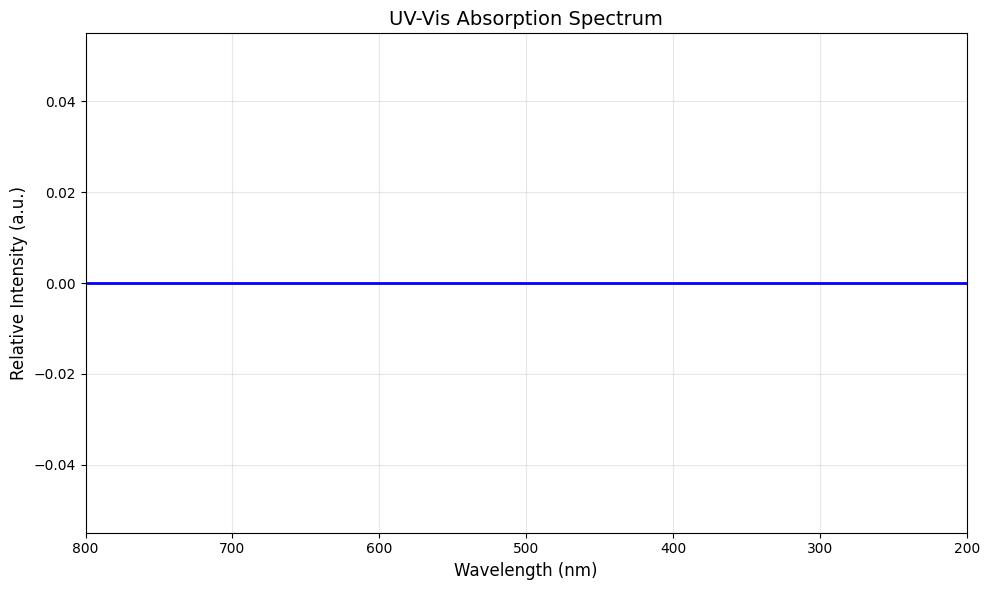


Excitation Summary
State  Energy (eV)  Wavelength (nm) Osc. Str.   
------------------------------------------------------------
1      56.1454      22.08           0.057643    
2      57.9640      21.39           0.103547    
3      57.9640      21.39           0.103547    
4      67.8527      18.27           0.047845    
5      81.2831      15.25           0.002807    
6      144.4943     8.58            0.000013    
7      146.3236     8.47            0.000094    
8      146.3236     8.47            0.000094    
9      147.5620     8.40            0.000000    
10     147.5620     8.40            0.000000    
11     148.9527     8.32            0.000012    
12     155.4409     7.98            0.000012    
13     157.0461     7.89            0.000064    
14     157.0461     7.89            0.000064    
15     168.5736     7.35            0.000000    
16     173.1034     7.16            0.000544    
17     173.1034     7.16            0.000544    
18     177.8298     6.97            0

(array([22.08265782, 21.38983467, 21.38983467, 18.27253549, 15.25335764,
         8.58054729,  8.47327599,  8.47327599,  8.40216521,  8.40216521,
         8.3237143 ,  7.97628025,  7.89475419,  7.89475419,  7.35489044,
         7.16242557,  7.16242557,  6.97205863,  5.43373597,  4.60663545]),
 array([ 56.14541555,  57.96398238,  57.96398238,  67.85265243,
         81.28308726, 144.4942797 , 146.32357084, 146.32357084,
        147.56196401, 147.56196401, 148.95273368, 155.44087736,
        157.04605489, 157.04605489, 168.57355112, 173.1033696 ,
        173.1033696 , 177.82982993, 228.17450239, 269.14220004]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Your computed values (example placeholders - replace with your actual variables)
# exc_energies: in Hartree (atomic units)
# osc_strengths: dimensionless oscillator strengths

# 1. Convert excitation energies from Hartree to eV
hartree_to_ev = 27.2114
energies_ev = exc_energies * hartree_to_ev

# 2. Convert to wavelength (nm)
# E(eV) = 1239.84 / λ(nm)
wavelengths_nm = 1239.84 / energies_ev

# 3. Create the spectrum with Gaussian broadening
def plot_spectrum(exc_energies_aU, osc_strengths, sigma_eV=0.3, xlim_nm=(200, 800)):
    """
    Generate a UV-Vis spectrum from PySCF excitation data.
    
    Parameters:
    - exc_energies_aU: Excitation energies in atomic units (Hartree)
    - osc_strengths: Oscillator strengths (dimensionless)
    - sigma_eV: Gaussian width in eV (typical: 0.2-0.4 eV)
    - xlim_nm: Wavelength range in nm
    """
    # Constants
    hartree_to_ev = 27.2114
    ev_to_wl = 1239.84  # E(eV) * λ(nm) = 1239.84
    
    # Convert to eV
    energies_ev = exc_energies_aU * hartree_to_ev
    wavelengths_nm = ev_to_wl / energies_ev
    
    # Create wavelength axis for plotting
    wl_plot = np.linspace(xlim_nm[0], xlim_nm[1], 1000)
    energy_plot = ev_to_wl / wl_plot  # Corresponding energy axis
    
    # Initialize spectrum intensity
    spectrum = np.zeros_like(wl_plot)
    
    # Add Gaussian peaks for each transition
    for e_ev, f in zip(energies_ev, osc_strengths):
        # Gaussian: I(E) = f * exp(-(E - E_exc)^2 / (2σ²))
        gaussian = np.exp(-((energy_plot - e_ev)**2) / (2 * sigma_eV**2))
        spectrum += f * gaussian
    
    # Normalize for display
    max_intensity = np.max(spectrum)
    if max_intensity > 0:
        spectrum /= max_intensity
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(wl_plot, spectrum, color='blue', linewidth=2)
    
    # Optional: Mark individual transitions
    for wl, f in zip(wavelengths_nm, osc_strengths):
        plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Relative Intensity (a.u.)', fontsize=12)
    plt.title('UV-Vis Absorption Spectrum', fontsize=14)
    plt.xlim(xlim_nm[1], xlim_nm[0])  # Invert x-axis (standard for UV-Vis)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print table of transitions
    print("\n" + "="*60)
    print("Excitation Summary")
    print("="*60)
    print(f"{'State':<6} {'Energy (eV)':<12} {'Wavelength (nm)':<15} {'Osc. Str.':<12}")
    print("-"*60)
    for i, (ev, wl, f) in enumerate(zip(energies_ev, wavelengths_nm, osc_strengths)):
        print(f"{i+1:<6} {ev:<12.4f} {wl:<15.2f} {f:<12.6f}")
    print("="*60)
    
    return wavelengths_nm, energies_ev, spectrum

# Call the function
plot_spectrum(exc_energies, osc_strengths, sigma_eV=0.3)

## VQE methods

1. Fast VQE
2. OOFast VQE
3. Adapt VQE
4. OOAdapt VQE

In [ ]:
# Build the molecular configuration
molecular_configuration = qc.build_molecular_configuration(
        molecule=molecule,
        basis_set=basis,
    )

# Build the ground state problem.
problem_builder = (
        qc.problem_builder_creator()
        .ground_state()
        .standard()
        .add_problem_modifier()
        .active_space(
            number_of_active_spatial_orbitals=num_active_orbs,
            number_of_active_alpha_electrons=num_active_alpha_electrons,
        )
        .create()
    )

ground_state_problem = problem_builder.build_restricted(molecular_configuration)


# Define the different calculators

gate_selector = qc.gate_selector_creator().adapt().create()

calculators = {

"fast_vqe":
        qc.calculator_creator()
        .vqe()
        .iterative()
        .standard()
        .with_options(
                options=qc.options.IterativeVqeOptions(max_iterations=1_000,)
        )
        .choose_stopping_criterion(
        )
        .patience(
                patience=10,
                threshold=1e-10
        )
        # .choose_minimizer()
        # .scipy(method="L-BFGS-B", options=qc.options.ScipyMinimizerOptions(jacobian_step_size=1e-9))
        .create(),

"oofast_vqe":
        qc.calculator_creator()
        .vqe()
        .iterative_with_orbital_optimization()
        .standard()
        .with_options(
                options=qc.options.IterativeVqeOptions(max_iterations=1_000,)
        )
        .create(),

"adapt_vqe":
        qc.calculator_creator()
        .vqe()
        .iterative()
        .standard()
        .with_options(
                options=qc.options.IterativeVqeOptions(max_iterations=1_000,)
        )
        .with_gate_selector(gate_selector)
        .create(),

"ooadapt_vqe": 
        qc.calculator_creator()
        .vqe()
        .iterative_with_orbital_optimization()
        .standard()
        .with_options(
                options=qc.options.IterativeVqeOptions(max_iterations=1_000,)
        )
        .with_gate_selector(gate_selector)
        .create()
}

results = {'FCI (Ground Truth)': fci_gse}

for calculator in calculators.keys():
    results[calculator] = calculators[calculator].calculate(ground_state_problem).total_energy.value




capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.


KeyboardInterrupt: 

In [ ]:
fast_vqe_calculator = calculators["fast_vqe"]

In [ ]:
estimator = (
    qc.estimator_creator()
    .memory_restricted() # faster but not accurate. --> for more precision use state vector
    .with_precise_defaults()
    .create()
)

In [ ]:
res = fast_vqe_calculator.calculate(ground_state_problem)
res

AdaptiveVqeGroundStateProblemCalculatorResult(initial_active_electrons_energy=np.float64(-8.857341498221166), non_active_electrons_energy=np.float64(0.0), nuclear_repulsion=np.float64(0.995317638094044), second_order_correction=ExpectationValue(value=0.0, error=0.0), uncorrected_active_electrons_energy=ExpectationValue(value=-8.877707462885546, error=0.0), active_electrons_energy_per_macro_iteration=ListOfExpectationValues([ExpectationValue(value=-8.871854251172792, error=0.0), ExpectationValue(value=-8.873752452317671, error=0.0), ExpectationValue(value=-8.87550634043927, error=0.0), ExpectationValue(value=-8.87606597414947, error=0.0), ExpectationValue(value=-8.876597292487844, error=0.0), ExpectationValue(value=-8.876684855873643, error=0.0), ExpectationValue(value=-8.877137221702002, error=0.0), ExpectationValue(value=-8.877152809512147, error=0.0), ExpectationValue(value=-8.87716831153677, error=0.0), ExpectationValue(value=-8.877185467228239, error=0.0), ExpectationValue(value=-8

In [ ]:
res.final_circuit

In [ ]:
# Compare RDMs

# FCI --> python lib
# Qrunch --> ReducedDensityMatrixCalculator

# full active space --> fci (classical)
# otherwise use the cas-sfcs (classical)

In [ ]:
rdm_calculator = ReducedDensityMatrixCalculator(
    estimator=estimator,
    # Additional parameters may be needed (shots, backend, etc.)
)

rdm1 = rdm_calculator.calculate_1_rdm(circuit=res.final_circuit, shots=None) # None --> until conversion
rdm2 = rdm_calculator.calculate_2_rdm(circuit=res.final_circuit, shots=None)
rdm3 = rdm_calculator.calculate_3_rdm(circuit=res.final_circuit, shots=None)
rdm4 = rdm_calculator.calculate_4_rdm(circuit=res.final_circuit, shots=None)

In [ ]:
rdm1.shape

(6, 6)

In [ ]:
rdm2.shape

(6, 6, 6, 6)

In [ ]:
rdm3.shape

(4, 4, 4, 4, 4, 4)

In [ ]:
rdm4.shape

(6, 6, 6, 6, 6, 6, 6, 6)

In [ ]:
rdm1

array([[ 1.99991416e+00, -2.88168027e-04,  6.38649520e-04,
         1.16194846e-09,  0.00000000e+00, -1.25321804e-03],
       [-2.88168027e-04,  1.95187134e+00,  7.34428390e-02,
         9.90209956e-11,  0.00000000e+00,  1.08133035e-02],
       [ 6.38649520e-04,  7.34428390e-02,  1.23373007e-02,
         4.36262426e-12,  0.00000000e+00, -1.72399560e-02],
       [ 1.16194846e-09,  9.90209956e-11,  4.36262426e-12,
         1.51566352e-03,  0.00000000e+00,  9.41575579e-13],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.51540336e-03,  0.00000000e+00],
       [-1.25321804e-03,  1.08133035e-02, -1.72399560e-02,
         9.41575579e-13,  0.00000000e+00,  3.28461358e-02]])

In [ ]:
fci_rdm1

array([[ 1.99990675e+00, -4.05835021e-04,  1.08869995e-03,
        -4.63233449e-17, -3.72186640e-17,  1.12848600e-03],
       [-4.05835021e-04,  1.95176766e+00, -1.86241647e-02,
        -8.59481991e-16, -1.80470160e-15,  7.21978877e-02],
       [ 1.08869995e-03, -1.86241647e-02,  4.21594719e-02,
         1.45020423e-16,  3.24882063e-16, -4.71131472e-03],
       [-4.63233449e-17, -8.59481991e-16,  1.45020423e-16,
         1.52459928e-03, -5.79398154e-19, -2.70799040e-17],
       [-3.72186640e-17, -1.80470160e-15,  3.24882063e-16,
        -5.79398154e-19,  1.52459928e-03, -5.18109715e-17],
       [ 1.12848600e-03,  7.21978877e-02, -4.71131472e-03,
        -2.70799040e-17, -5.18109715e-17,  3.11692050e-03]])

In [ ]:
# compare the results

np.allclose(fci_rdm1, rdm1, atol=1e-1, rtol=1e-4)

True

In [ ]:
# DOES NOT WORK


# Classical RDM
mol = gto.M(
    atom=molecule,
    basis=basis,
    unit='Angstrom',
    )

hf_energy = mol.RHF().run()
# moller_plesset = mp.MP2(hf_energy).run()


casscf = mcscf.CASSCF(hf_energy, ncas=num_active_orbs, nelecas=num_active_alpha_electrons*2) # x2 for alpha and beta electrons
casscf.kernel()

# Compute the one-particle reduced density matrix (RDM1)
rdm1_classical = casscf.make_rdm1()

# Compute the two-particle reduced density matrix (RDM2)
# rdm2 = casscf.make_rdm2()

converged SCF energy = -74.9623593200333
CASSCF energy = -75.0096931640882
CASCI E = -75.0096931640882  E(CI) = -6.23929633589925  S^2 = 0.0000000


In [ ]:
rdm1

array([[1.99175868, 0.        , 0.01852545, 0.        ],
       [0.        , 1.99781416, 0.        , 0.        ],
       [0.01852545, 0.        , 0.0063082 , 0.        ],
       [0.        , 0.        , 0.        , 0.00411896]])

In [ ]:
rdm1_classical

array([[ 2.10703038e+00, -4.51640968e-01, -4.34369643e-08,
        -8.07620556e-07, -1.07469878e-01, -2.32970311e-02,
        -2.32982266e-02],
       [-4.51640968e-01,  1.99724758e+00,  2.60142609e-07,
         3.76340832e-06,  6.03230282e-01, -6.06231382e-02,
        -6.06174435e-02],
       [-4.34369643e-08,  2.60142609e-07,  2.00000000e+00,
        -2.12313586e-07, -2.85336873e-07,  6.23185282e-09,
        -4.18666314e-07],
       [-8.07620556e-07,  3.76340832e-06, -2.12313586e-07,
         7.34550571e-01,  2.58538244e-06,  5.04615604e-01,
        -5.04617935e-01],
       [-1.07469878e-01,  6.03230282e-01, -2.85336873e-07,
         2.58538244e-06,  1.23873063e+00, -4.66915579e-01,
        -4.66912849e-01],
       [-2.32970311e-02, -6.06231382e-02,  6.23185282e-09,
         5.04615604e-01, -4.66915579e-01,  6.38059387e-01,
        -1.71395655e-01],
       [-2.32982266e-02, -6.06174435e-02, -4.18666314e-07,
        -5.04617935e-01, -4.66912849e-01, -1.71395655e-01,
         6.3805536

In [ ]:
rdm1.shape

(7, 7)

In [ ]:
t[1].shape

(7, 7)

In [ ]:
results

{'FCI (Ground Truth)': np.float64(-75.01375703590888),
 'fast_vqe': -74.96999434879562,
 'oofast_vqe': -74.96999361910065,
 'adapt_vqe': -74.96999436942338,
 'ooadapt_vqe': -74.96999545207203}

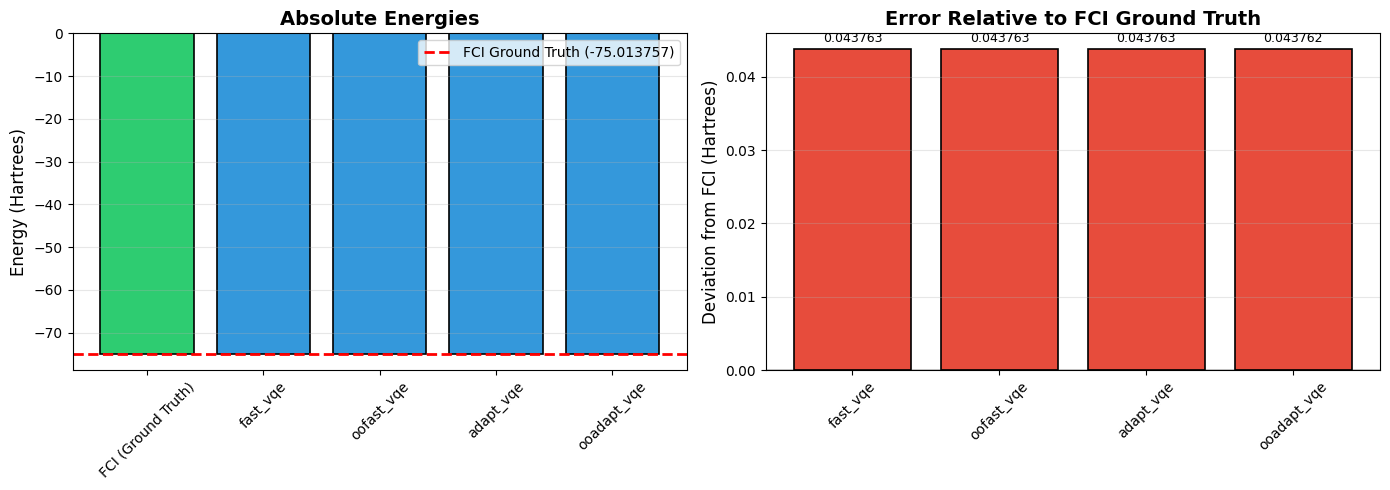

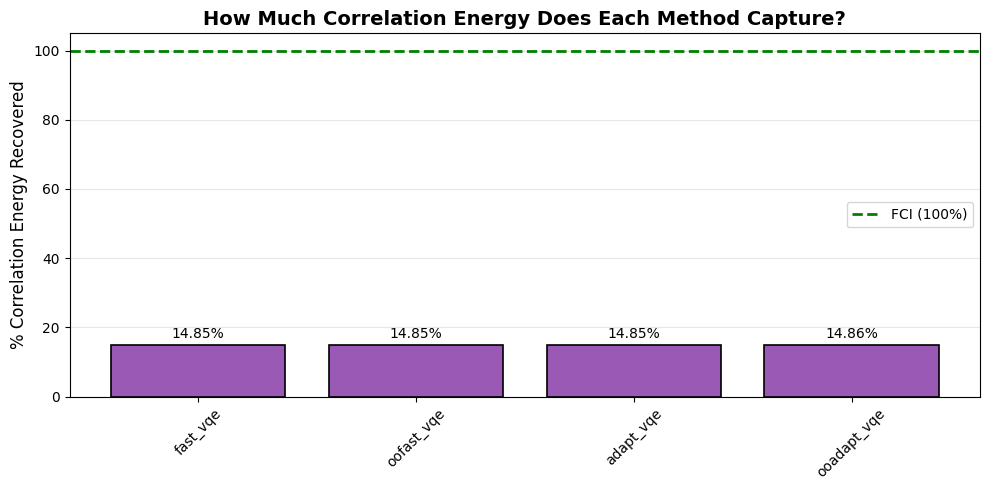

QUANTUM CHEMISTRY METHOD COMPARISON SUMMARY

HF Energy:                    -74.9623593200 Ha
FCI Energy (Ground Truth):    -75.0137570359 Ha
Total Correlation Energy:     -0.0513977159 Ha
----------------------------------------------------------------------
Method               Energy (Ha)          Deviation       % Corr. Rec.   
----------------------------------------------------------------------
fast_vqe             -74.9699943651       0.0437626708    14.85          %
oofast_vqe           -74.9699936191       0.0437634168    14.85          %
adapt_vqe            -74.9699943637       0.0437626723    14.85          %
ooadapt_vqe          -74.9699954521       0.0437615838    14.86          %


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
# results = {
#     'FCI (Ground Truth)': -75.0137570359089,
#     'Fast VQE': -74.96999435006403,
#     'OO Fast VQE': -74.96999361910181,
#     'Adapt VQE': -74.96999436517271,
#     'OO Adapt VQE': -74.96999545207179
# }

# Calculate deviations from FCI
fci_energy = results['FCI (Ground Truth)']
deviations = {method: energy - fci_energy for method, energy in results.items()}

# Calculate correlation energy (difference between HF and FCI)
# Assuming your HF was around -74.962 (from earlier)
hf_energy = -74.9623593200333
correlation_energy = fci_energy - hf_energy  # Negative value

# Calculate % correlation energy recovered
percent_recovered = {}
for method, energy in results.items():
    if method != 'FCI (Ground Truth)':
        method_corr = energy - hf_energy
        percent_recovered[method] = (method_corr / correlation_energy) * 100

# ============================================
# Plot 1: Absolute Energies
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = list(results.keys())
energies = list(results.values())
colors = ['#2ecc71' if m == 'FCI (Ground Truth)' else '#3498db' for m in methods]

axes[0].bar(methods, energies, color=colors, edgecolor='black', linewidth=1.2)
axes[0].axhline(y=fci_energy, color='red', linestyle='--', linewidth=2, 
                label=f'FCI Ground Truth ({fci_energy:.6f})')
axes[0].set_ylabel('Energy (Hartrees)', fontsize=12)
axes[0].set_title('Absolute Energies', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ============================================
# Plot 2: Deviation from FCI (More Informative!)
# ============================================
vqe_methods = [m for m in methods if m != 'FCI (Ground Truth)']
vqe_deviations = [deviations[m] for m in vqe_methods]

bars = axes[1].bar(vqe_methods, vqe_deviations, color='#e74c3c', 
                   edgecolor='black', linewidth=1.2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_ylabel('Deviation from FCI (Hartrees)', fontsize=12)
axes[1].set_title('Error Relative to FCI Ground Truth', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, vqe_deviations)):
    axes[1].annotate(f'{val:.6f}', 
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('vqe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Plot 3: Correlation Energy Recovery (%)
# ============================================
fig, ax = plt.subplots(figsize=(10, 5))
methods_for_recovery = list(percent_recovered.keys())
percentages = list(percent_recovered.values())

bars = ax.bar(methods_for_recovery, percentages, color='#9b59b6', 
              edgecolor='black', linewidth=1.2)
ax.axhline(y=100, color='green', linestyle='--', linewidth=2, label='FCI (100%)')
ax.set_ylabel('% Correlation Energy Recovered', fontsize=12)
ax.set_title('How Much Correlation Energy Does Each Method Capture?', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, pct in zip(bars, percentages):
    ax.annotate(f'{pct:.2f}%', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('correlation_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Print Summary Table
# ============================================
print("=" * 70)
print("QUANTUM CHEMISTRY METHOD COMPARISON SUMMARY")
print("=" * 70)
print(f"\nHF Energy:                    {hf_energy:.10f} Ha")
print(f"FCI Energy (Ground Truth):    {fci_energy:.10f} Ha")
print(f"Total Correlation Energy:     {correlation_energy:.10f} Ha")
print("-" * 70)
print(f"{'Method':<20} {'Energy (Ha)':<20} {'Deviation':<15} {'% Corr. Rec.':<15}")
print("-" * 70)
for method in vqe_methods:
    print(f"{method:<20} {results[method]:<20.10f} {deviations[method]:<15.10f} {percent_recovered[method]:<15.2f}%")
print("=" * 70)